使用3d-OT分析乳腺癌数据集并计算ARI

In [5]:
from lib_3d_OT.utils import *
import scanpy as sc
import numpy as np
import pandas as pd
import torch
from lib_3d_OT.single_modialty import *
import torch.optim as optim
import warnings
warnings.filterwarnings("ignore")

/home/zhangjunyi/anaconda3/envs/3d-OT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



In [7]:
# 优先使用 GPU 0（你的空闲显卡）
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("当前运行设备：", device)
print("GPU 是否可用：", torch.cuda.is_available())

当前运行设备： cuda:0
GPU 是否可用： True


加载数据

In [21]:
# 3D-OT 空间数据预处理（适配你的乳腺癌数据集）
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import warnings
warnings.filterwarnings("ignore")

# ===================== 【核心修改】你的数据集完整路径 =====================
data_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC"

# 读取10x Visium空间转录组数据
adata = sc.read_visium(data_dir)
adata.var_names_make_unique()

# 标准数据预处理流程（3D-OT官方教程流程）
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat_v3')
adata = adata[:, adata.var.highly_variable]
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.scale(adata, zero_center=False, max_value=10)

# ===================== 读取真实标签（保持你原有的标签路径） =====================
cluster = pd.read_csv('/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/metadata.tsv', sep='\t', index_col=0)
# adata.obs['truth'] = cluster['ground_truth']
# adata.obs['truth'] = adata.obs['truth'].astype('category')
#修改注释结果为annot_type
adata.obs['truth'] = cluster['annot_type']
adata.obs['truth'] = adata.obs['truth'].astype('category')



# 模型输入特征
adata.obsm['feat'] = adata.X

# ===================== 【必看】GPU设置（使用你空闲的A100显卡） =====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("数据加载完成！")
print(f"当前使用设备: {device}")
print(f"数据维度: {adata.shape}")

数据加载完成！
当前使用设备: cuda:0
数据维度: (3798, 3000)


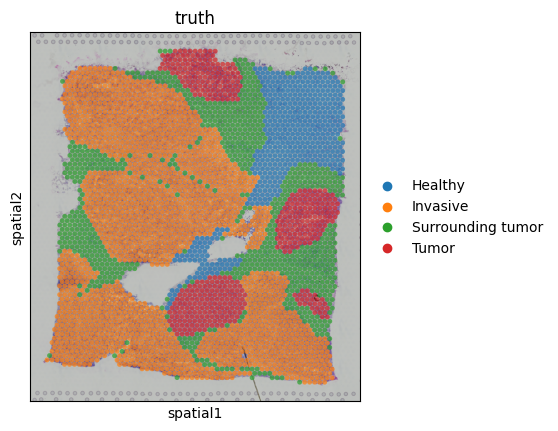

In [23]:
sc.pl.spatial(adata, img_key="hires", color="truth", alpha=0.7, size=1.5)

构造邻居图并训练 PointNet++Encoder

In [24]:
set_seed(8)
graph = prepare_data(adata, location="spatial", nb_neighbors=16).to(device)
input_dim1 = graph.express.shape[-1]
model = extractMODEL(args=None,input_dim=input_dim1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
best_model, min_loss = train_graph_extractor(graph, model, optimizer, device,epochs=1150)

Epoch 1150/1150, Loss: 0.682635, Min Loss: 0.682920

In [25]:
# 获得重建矩阵
with torch.no_grad():
    model.eval()
    z= model.get_features(graph)
    decoded_features = model.decode(z)
    gene_expression_matrix = decoded_features.cpu().squeeze(0).detach().numpy()
adata.obsm['3d-OT']=gene_expression_matrix

In [26]:
#我们使用 mclust 进行聚类
clustering(adata, n_clusters=2, radius=50, key='3d-OT', method='mclust', refinement=True,random=38,n_comp=10)

Using 3d-OT representation for clustering...
fitting ...
  |======================================================================| 100%


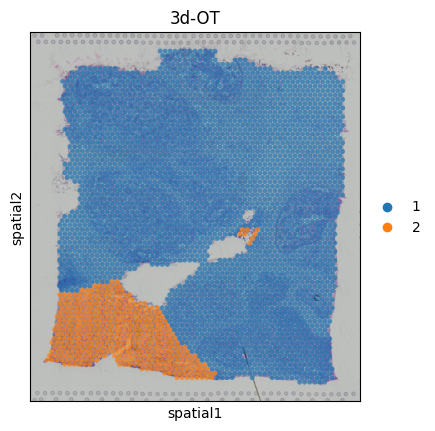

In [27]:
# 乳腺癌的聚集结果
sc.pl.spatial(adata, color='3d-OT', img_key='hires', alpha=0.7, size=1.5)


In [30]:
#计算监督指标ARI和NMI
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ARI = adjusted_rand_score(adata.obs['truth'], adata.obs['3d-OT'])
NMI = normalized_mutual_info_score(adata.obs['truth'], adata.obs['3d-OT'])
ARI,NMI
# 3. 定义保存路径（你指定的绝对路径）
save_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/3d-OT/"
os.makedirs(save_dir, exist_ok=True)  # 自动创建文件夹（不存在也不报错）
save_path = os.path.join(save_dir, "3d-OT_ARI_NMI_k2_ARI_NMI.csv")

# 4. 保存为CSV
result_df = pd.DataFrame({
    "Dataset": ["Human_breast_cancer_ViHBC", "Human_breast_cancer_ViHBC"],
    "Method": ["3d-OT", "3d-OT"],
    "Metric": ["ARI", "NMI"],
    "Score": [round(ARI, 4), round(NMI, 4)]
})
result_df.to_csv(save_path, index=False)

print(f"\n✅ 指标已保存到：\n{save_path}")


✅ 指标已保存到：
/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/3d-OT/3d-OT_ARI_NMI_k2_ARI_NMI.csv
